In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import torch

from transformers import AutoModelForCausalLM, GPT2Tokenizer, logging

logging.set_verbosity_error()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [6]:
# import tokenizer and model
model_name = 'gpt2-xl'

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

model.eval();

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

# Import sentences with the work " her"

In [5]:
# sentences generated by Claude.ai
sentences = [
    "I saw her at the market.",
    "She gave her the book.",
    "They asked her for advice.",
    "We invited her to dinner.",
    "The dog followed her home.",
    "They asked her to join.",
    "He saw her at the park yesterday.",
    "Did you give her your address?",
    "I haven't seen her in ages.",
    "I told her the truth.",
    "They congratulated her on his success.",
    "She recognized her immediately.",
    "The teacher praised her for his work.",
    "I met her last summer.",
    "The child hugged her tightly.",
    "They warned her about the danger.",
    "She drove her to the airport.",
    "We waited for her for hours.",
    "The cat scratched her accidentally.",
    "They surprised her with a gift.",
    "She called her on the phone.",
    "The jury found her not guilty.",
    "I remembered her from school.",
    "They elected her as president.",
    "She forgave her for his mistake.",
    "The police questioned her yesterday.",
    "I helped her with his homework.",
    "They spotted her in the crowd.",
    "She visited her in the hospital.",
    "The manager promoted her last week.",
    "I trusted her completely.",
    "They respected her for his honesty.",
    "She taught her how to swim.",
    "The bird attacked her suddenly.",
    "I greeted her warmly.",
    "They supported her through difficult times.",
    "She ignored her at the party.",
    "The judge sentenced her to community service.",
    "I photographed her during the event.",
    "They believed her despite the evidence.",
    "She surprised her on his birthday.",
    "The guard stopped her at the entrance.",
    "I missed her terribly.",
    "They watched her leave the building.",
    "She accompanied her to the concert.",
    "The crowd cheered her enthusiastically.",
    "I described her to the police.",
    "They thanked her for his help.",
    "She admired her for his courage.",
    "The committee nominated her for the award.",
    "I married her last spring.",
    "They informed her about the changes.",
    "She introduced her to the parents.",
    "The author based the character on her."
]

target_token = tokenizer.encode(' her')[0]
print(f'There are {len(sentences)} sentences.')

There are 54 sentences.


# Run the sentences through the model

In [7]:
tokens = tokenizer(sentences, return_tensors='pt', padding=True).to(device)

with torch.no_grad():
  output = model(**tokens, output_hidden_states=True)

In [8]:
num_hidden_layers = len(output.hidden_states)
print(f'There are {num_hidden_layers} hidden layers.')

There are 49 hidden layers.


# Determine the angle between target and its previous token in layer 0

In [45]:
output.hidden_states[0][3,2].shape

torch.Size([1600])

In [59]:
# Initialize
angles = np.zeros((num_hidden_layers, len(sentences),2))

for senti in range(len(sentences)):
  current_sent_tokens = tokens['input_ids'][senti][tokens['attention_mask'][senti].bool()]
  target_idx = current_sent_tokens.tolist().index(target_token)

  non_target_idx = np.sort(np.random.choice(np.where(current_sent_tokens != target_token)[0],2, replace=False))

  for layeri in range(num_hidden_layers):

      # Determine the angle between target token and the prvious token
      u = output.hidden_states[layeri][senti, target_idx-1, :].detach().squeeze()
      v = output.hidden_states[layeri][senti, target_idx, :].detach().squeeze()
      angle = torch.acos(torch.dot(u, v) / (torch.norm(u) * torch.norm(v)))
      angles[layeri, senti, 0] = angle.item()

      # Determine the angle between two random non_target tokens
      u = output.hidden_states[layeri][senti, non_target_idx[0], :].detach().squeeze()
      v = output.hidden_states[layeri][senti, non_target_idx[1], :].detach().squeeze()
      angle = torch.acos(torch.dot(u, v) / (torch.norm(u) * torch.norm(v)))
      angles[layeri, senti, 1] = angle.item()

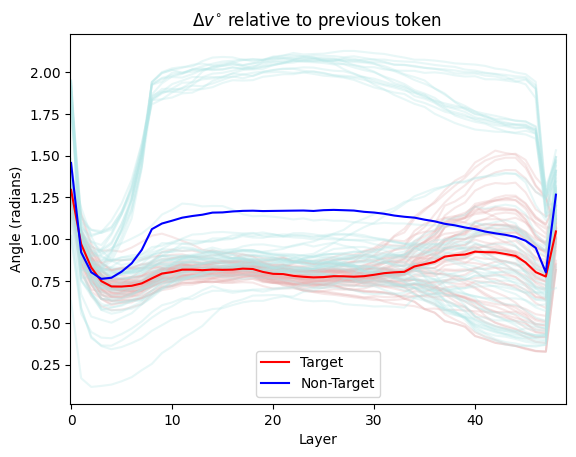

In [79]:
# Visualize

plt.plot(np.arange(num_hidden_layers), angles[:,:,0], c=[.9,.7,.7, .3])
plt.plot(np.arange(num_hidden_layers), angles[:,:,1], c=[.7,.9,.9, .3])

plt.plot(np.arange(num_hidden_layers), np.mean(angles[:,:,0], axis=1), c='red', label='Target')
plt.plot(np.arange(num_hidden_layers), np.mean(angles[:,:,1], axis=1), c='blue', label='Non-Target')

plt.gca().set(xlabel='Layer', ylabel='Angle (radians)', xlim=[-.1, num_hidden_layers], title='$\\Delta v^{\\circ}$ relative to previous token ')


plt.legend()
plt.show()

# Find angles between two successive tokens

In [81]:
angles = np.zeros((num_hidden_layers, len(sentences),4))

for senti in range(len(sentences)):
  for layeri in range(num_hidden_layers):
    for toki in range(4):

      u = output.hidden_states[layeri][senti, toki, :].detach().squeeze()
      v = output.hidden_states[layeri][senti, toki+1, :].detach().squeeze()

      angles[layeri, senti, toki] = torch.acos(torch.dot(u, v) / (torch.norm(u) * torch.norm(v))) * (180/np.pi)

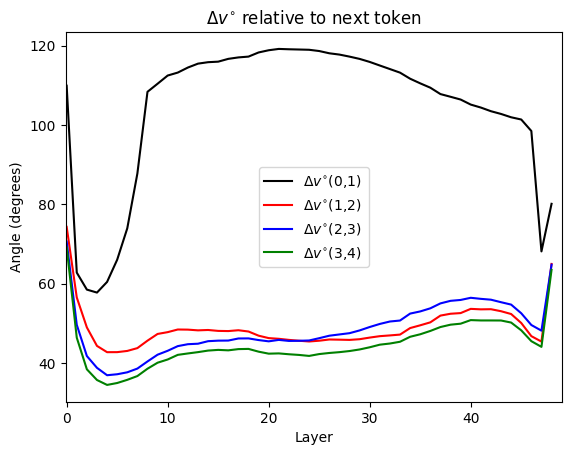

In [89]:
# Visualize
c = ['k','r','b','g']
for i in range(4):
  plt.plot(np.mean(angles[:,:,i], axis=1), c=c[i], label=f'$\\Delta v^{{\\circ}}$({i},{i+1}) ')

plt.gca().set(xlabel='Layer', ylabel='Angle (degrees)', xlim=[-.1, num_hidden_layers], title='$\\Delta v^{\\circ}$ relative to next token')
plt.legend()
plt.show()